In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('weather_prediction_dataset.csv')
dates = pd.date_range('2000-01-01', '2010-12-31', freq='D')
if len(df) != len(dates):
    dates = dates[:len(df)]
df['date'] = dates
df = df[['date', 'BASEL_temp_max']].rename(columns={'BASEL_temp_max': 'max_temp'})
df = df.set_index('date')
df.head()

,max_temp
date,
2000-01-01,3.9
2000-01-02,4.8
2000-01-03,4.8
2000-01-04,7.5
2000-01-05,8.6


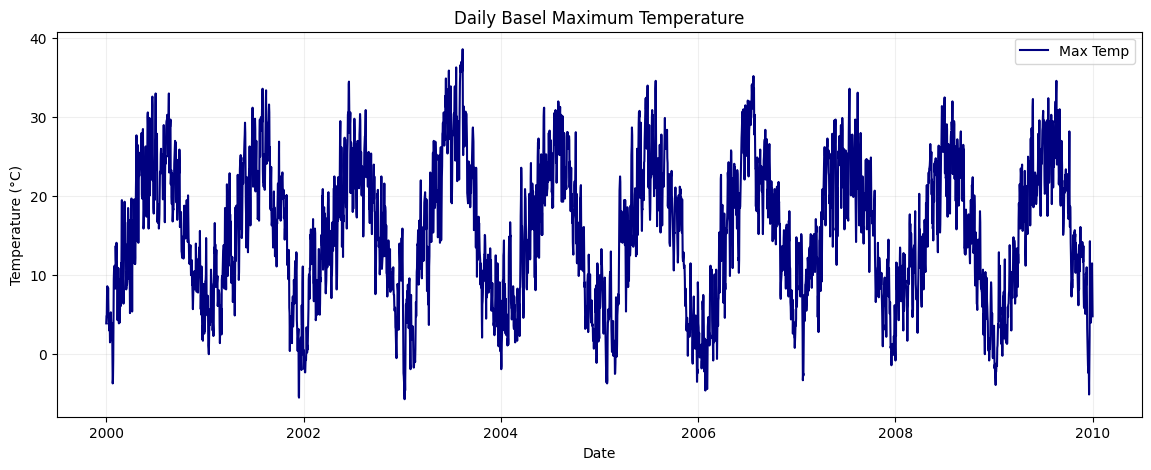

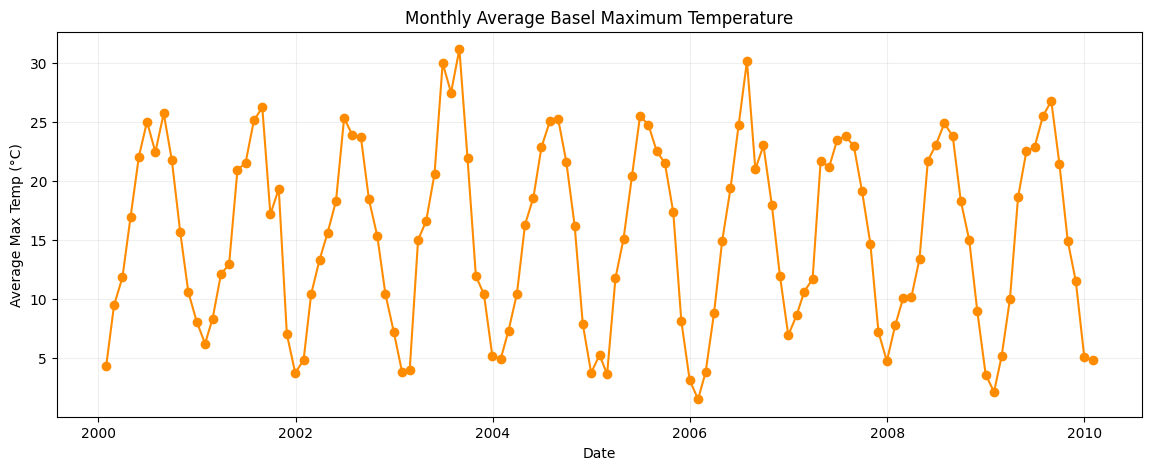

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['max_temp'], color='navy', label='Max Temp')
plt.title('Daily Basel Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()
monthly = df['max_temp'].resample('ME').mean()
plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, color='darkorange', marker='o')
plt.title('Monthly Average Basel Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Average Max Temp (°C)')
plt.grid(True, alpha=0.2)
plt.show()

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(df[['max_temp']].values)
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)
window_size = 30
X, y = create_sequences(scaled_values, window_size=window_size)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]
X_train.shape, X_val.shape, X_test.shape

((2536, 30, 1), (543, 30, 1), (545, 30, 1))

In [5]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(30),
    Dropout(0.2),
    Dense(10, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,441 (79.85 KB)

 Trainable params: 20,441 (79.85 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/100
80/80 - 4s - 47ms/step - loss: 0.0450 - mean_absolute_error: 0.1545 - val_loss: 0.0112 - val_mean_absolute_error: 0.0862 - learning_rate: 0.0010
Epoch 2/100
80/80 - 1s - 11ms/step - loss: 0.0148 - mean_absolute_error: 0.0977 - val_loss: 0.0127 - val_mean_absolute_error: 0.0919 - learning_rate: 0.0010
Epoch 3/100
80/80 - 1s - 11ms/step - loss: 0.0136 - mean_absolute_error: 0.0936 - val_loss: 0.0108 - val_mean_absolute_error: 0.0846 - learning_rate: 0.0010
Epoch 4/100
80/80 - 1s - 11ms/step - loss: 0.0131 - mean_absolute_error: 0.0928 - val_loss: 0.0116 - val_mean_absolute_error: 0.0878 - learning_rate: 0.0010
Epoch 5/100
80/80 - 1s - 11ms/step - loss: 0.0121 - mean_absolute_error: 0.0889 - val_loss: 0.0121 - val_mean_absolute_error: 0.0892 - learning_rate: 0.0010
Epoch 6/100
80/80 - 1s - 17ms/step - loss: 0.0115 - mean_absolute_error: 0.0864 - val_loss: 0.0093 - val_mean_absolute_error: 0.0781 - learning_rate: 0.0010
Epoch 7/100
80/80 - 1s - 11ms/step - loss: 0.0110 - mean_a

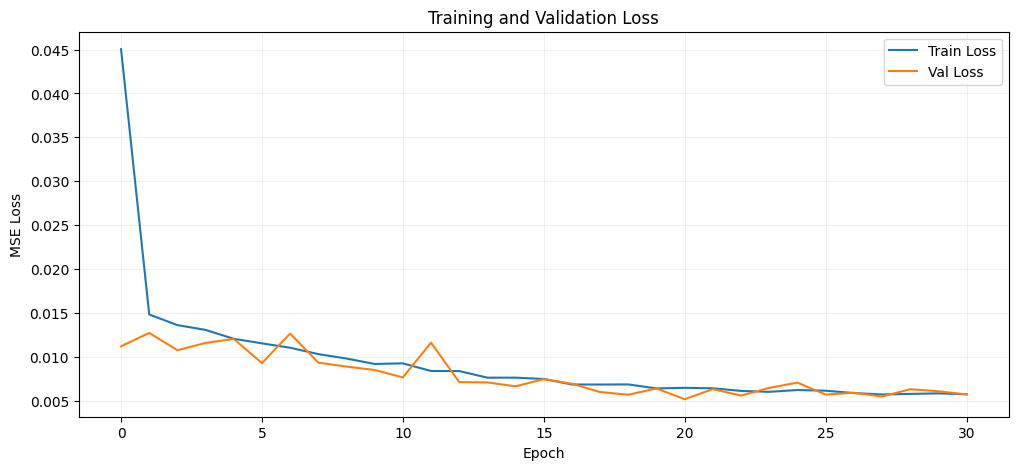

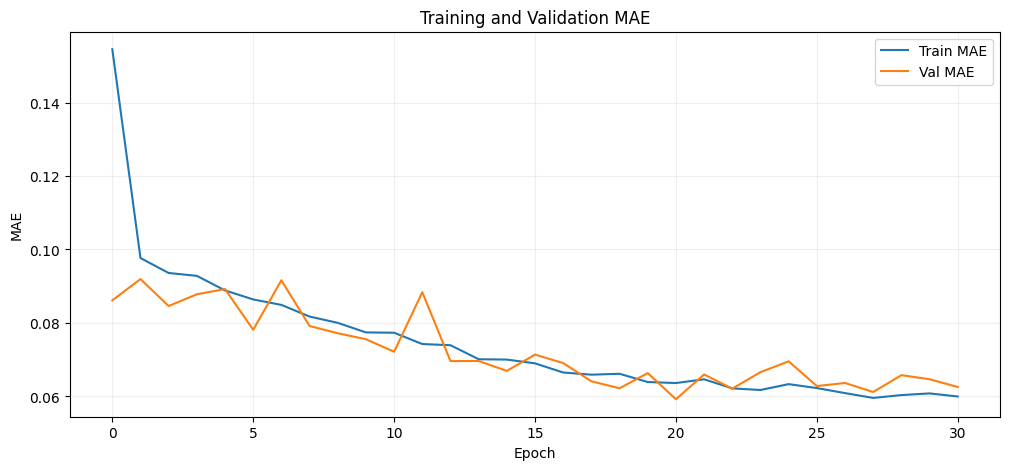

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('Images/training_mae_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled).ravel()
y_actual = scaler.inverse_transform(y_test).ravel()
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)
binary_accuracy = np.mean(np.abs(y_pred - y_actual) <= 2.0)
print(f'MAE: {mae:.3f} °C')
print(f'RMSE: {rmse:.3f} °C')
print(f'R2: {r2:.3f}')
print(f'Accuracy within ±2°C: {binary_accuracy * 100:.2f}%')

MAE: 2.598 °C
RMSE: 3.162 °C
R2: 0.873
Accuracy within ±2°C: 43.30%


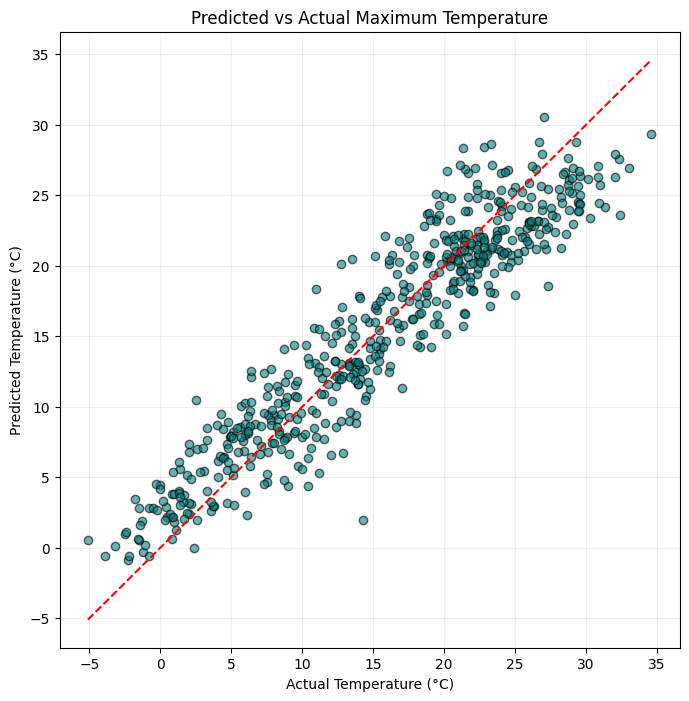

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred, alpha=0.6, color='teal', edgecolors='k')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
plt.title('Predicted vs Actual Maximum Temperature')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.grid(True, alpha=0.2)
plt.savefig('Images/pred_vs_actual_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

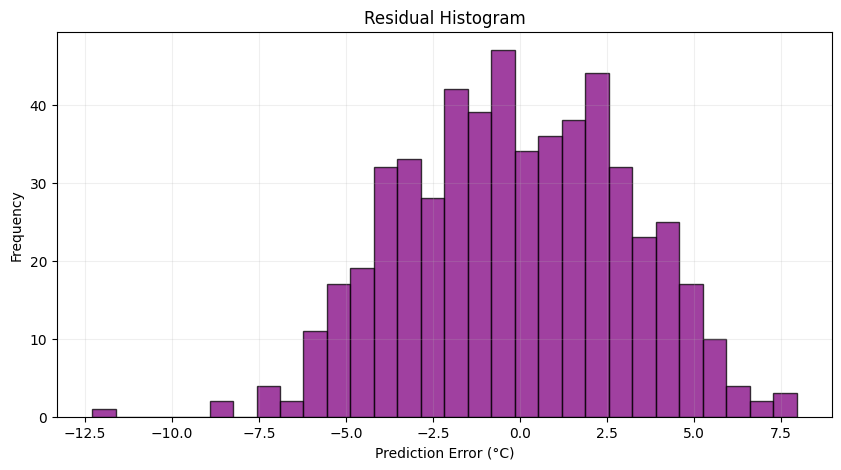

In [13]:
residuals = y_pred - y_actual
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30, color='purple', edgecolor='black', alpha=0.75)
plt.title('Residual Histogram')
plt.xlabel('Prediction Error (°C)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.2)
plt.savefig('Images/residuals_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

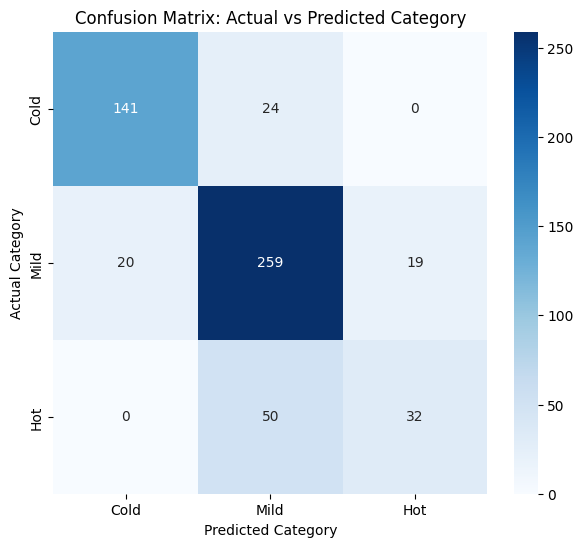

In [14]:
def temp_category(values):
    categories = []
    for v in values:
        if v < 10:
            categories.append('Cold')
        elif v <= 25:
            categories.append('Mild')
        else:
            categories.append('Hot')
    return categories
actual_cat = temp_category(y_actual)
pred_cat = temp_category(y_pred)
cm = confusion_matrix(actual_cat, pred_cat, labels=['Cold', 'Mild', 'Hot'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cold', 'Mild', 'Hot'], yticklabels=['Cold', 'Mild', 'Hot'])
plt.title('Confusion Matrix: Actual vs Predicted Category')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.savefig('Images/confusion_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
model.save('weather_lstm_model.h5')
joblib.dump(scaler, 'scaler.pkl')
print('Saved model to weather_lstm_model.h5 and scaler to scaler.pkl')

Saved model to weather_lstm_model.h5 and scaler to scaler.pkl


In [16]:
persistence_scaled = X_test[:, -1, 0].reshape(-1, 1)
persistence_actual = scaler.inverse_transform(persistence_scaled).ravel()
baseline_mae = mean_absolute_error(y_actual, persistence_actual)
improvement_pct = (baseline_mae - mae) / baseline_mae * 100 if baseline_mae != 0 else 0.0
print(f'Baseline persistence MAE: {baseline_mae:.3f} °C')
print(f'Model improvement over baseline: {improvement_pct:.2f}%')

Baseline persistence MAE: 2.428 °C
Model improvement over baseline: -7.00%


In [17]:
# Export a model architecture diagram for the report rubric
from tensorflow.keras.utils import plot_model

try:
    plot_model(
        model,
        to_file='Images/model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        dpi=96
    )
    print("Saved model architecture diagram to Images/model_architecture.png")
except Exception as e:
    print("Could not save model architecture diagram.")
    print("Error:", e)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Saved model architecture diagram to Images/model_architecture.png


In [18]:
# Build and print a formatted training parameter table
import tensorflow as tf

train_size = len(X_train)
val_size = len(X_val)
test_size = len(X_test)

learning_rate = getattr(model.optimizer, 'learning_rate', None)
if hasattr(learning_rate, 'numpy'):
    learning_rate = float(learning_rate.numpy())
optimizer_name = getattr(model.optimizer, 'name', model.optimizer.__class__.__name__)
loss_name = model.loss if isinstance(model.loss, str) else (
    model.loss.__name__ if callable(model.loss) else str(model.loss)
)
hardware = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'

params = {
    'Parameter': [
        'Training set size',
        'Validation set size',
        'Test set size',
        'Window size',
        'Batch size',
        'Epochs',
        'Learning rate',
        'Optimizer',
        'Loss function',
        'Hardware used'
    ],
    'Value': [
        train_size,
        val_size,
        test_size,
        window_size,
        32,
        100,
        learning_rate,
        optimizer_name,
        loss_name,
        hardware
    ]
}

params_df = pd.DataFrame(params)
print('Training parameters:')
print(params_df.to_string(index=False))

Training parameters:
          Parameter              Value
  Training set size               2536
Validation set size                543
      Test set size                545
        Window size                 30
         Batch size                 32
             Epochs                100
      Learning rate            0.00025
          Optimizer               adam
      Loss function mean_squared_error
      Hardware used                CPU


In [19]:
# Display a small sample of actual vs predicted values for demonstration
sample_df = pd.DataFrame({
    'Actual max temp': y_actual[:10],
    'Predicted max temp': y_pred[:10],
    'Error': (y_pred[:10] - y_actual[:10])
})

print('Actual vs. Predicted values (first 10 rows):')
print(sample_df.round(3).to_string(index=False))

Actual vs. Predicted values (first 10 rows):
 Actual max temp  Predicted max temp  Error
            22.3           24.768000  2.468
            22.4           22.468000  0.068
            20.0           22.166000  2.166
            24.1           20.747000 -3.353
            29.1           22.974001 -6.126
            28.5           26.628000 -1.872
            20.2           26.684000  6.484
            17.4           21.313999  3.914
            20.6           18.777000 -1.823
            24.7           20.240999 -4.459
